In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from astroML.linear_model import PolynomialRegression
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson
from sklearn.model_selection import train_test_split 

C:\Users\User\anaconda3\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


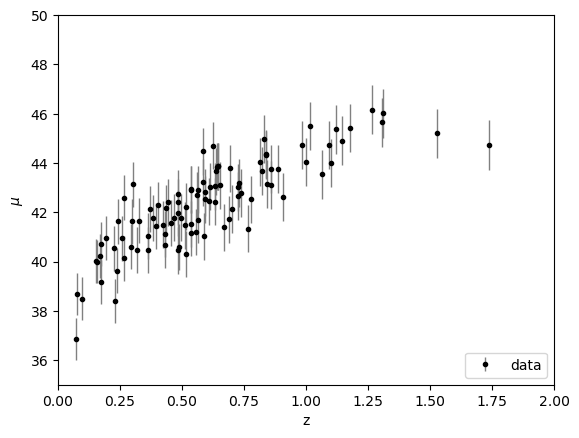

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [39]:
print(dmu)

[0.91862497 0.95818624 0.94340343 0.97222794 0.97171179 0.92819662
 0.92860378 0.97385018 0.9966678  0.98218018 0.93649091 0.948558
 0.96318467 0.9656542  0.93760835 0.95334492 0.94872528 0.86485225
 0.97103496 0.98306194 0.93712847 0.95764923 0.89710554 0.93748105
 0.99104229 0.96054687 0.93997207 0.97255426 0.93265984 0.95389152
 0.98131431 0.94327408 0.97387777 0.91153822 0.96493354 0.96496076
 0.92210777 0.98951197 0.94376982 0.98691576 0.89231065 0.91764268
 0.88762944 0.96247275 0.95599473 0.95113453 0.88588283 0.95336368
 0.93388642 0.94871596 0.90572161 0.95699473 0.95372094 0.85295833
 0.95781273 0.98736141 0.97272887 1.01211963 0.99684655 0.97286954
 0.92951505 0.95841129 0.94671347 0.91917738 0.93867591 0.89019692
 0.94455508 1.00520951 0.9080577  0.90719541 0.96790571 0.95541351
 0.94618927 0.90474131 0.92335956 0.98549227 0.94164366 0.95133629
 0.85158066 0.93107145 0.943334   0.95738992 0.98835882 0.95847705
 0.96508125 0.91252869 0.96857855 0.97688395 0.95911907 0.943451

### linear regression

In [17]:
print(z_sample.shape)
z_fit = z_sample.reshape(-1,1)
print(z_fit.shape)

(100,)
(100, 1)


In [19]:
lin_reg = LinearRegression()
lin_reg.fit(z_fit, mu_sample, dmu)

LinearRegression()

In [23]:
theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_
X_grid = np.linspace(0, 2, 100).reshape(-1,1)
y_pred = lin_reg.predict(X_grid)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_18908\3535639619.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("r$\mu$")


(35.0, 50.0)

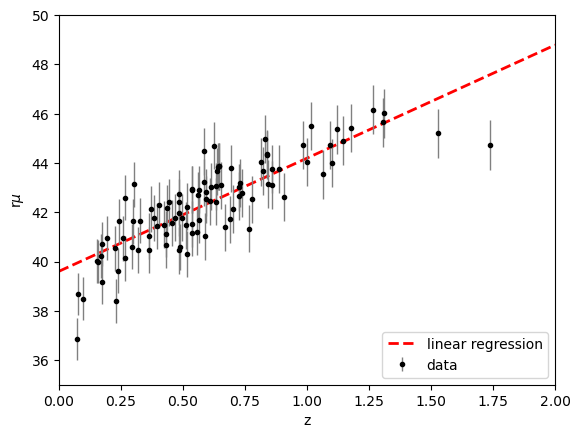

In [35]:
plt.plot(X_grid, y_pred, "r--", linewidth=2, label="linear regression")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"z")
plt.ylabel("r$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### polinomial regression

(35.0, 50.0)

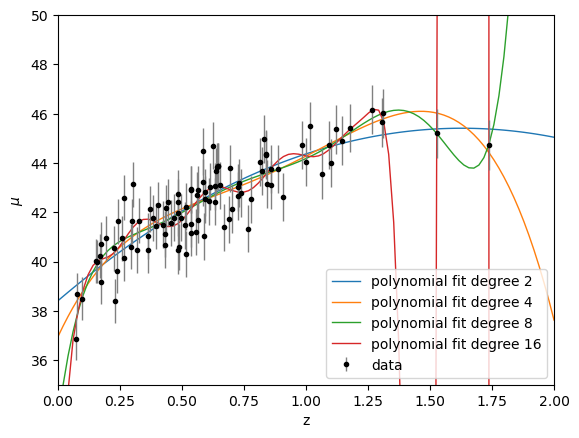

In [82]:
poli_index = [2,4,8,16]

for i in poli_index:
    model = PolynomialRegression(i)
    model.fit(z_fit, mu_sample, dmu)
    y_pred_poli = model.predict(X_grid)
    plt.plot(X_grid, y_pred_poli, linewidth=1, label=f"polynomial fit degree {i}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

based on my intuition degree four and degree 8 seems the better: degree two underfitting and degree 16 overfitting.

### basis function regression

In [57]:
# widths of these Gaussians
X_gridtest = np.linspace(0,2,10).reshape(-1,1)
sigma_test = 2.0/10.0
print(sigma_test)

model_basis_regression = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model_basis_regression.fit(z_fit, mu_sample, dmu)

y_pred_basis_regression = model_basis_regression.predict(X_grid)

0.2


(35.0, 50.0)

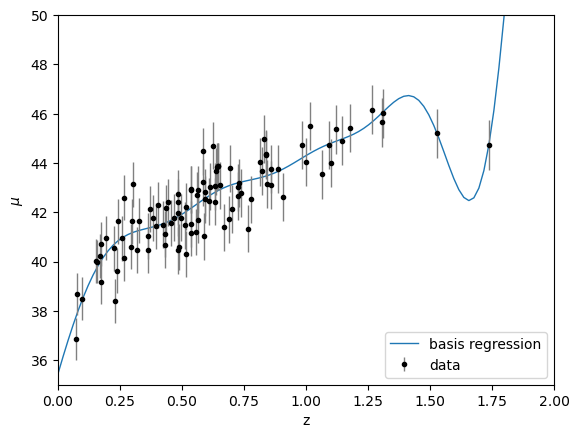

In [59]:
plt.plot(X_grid, y_pred_basis_regression, linewidth=1, label="basis regression")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Kernel regression

In [61]:
model_Watson = NadarayaWatson(kernel='gaussian', h=0.05)
model_Watson.fit(z_fit, mu_sample)
y_pred_Watson = model_Watson.predict(X_grid)

(35.0, 50.0)

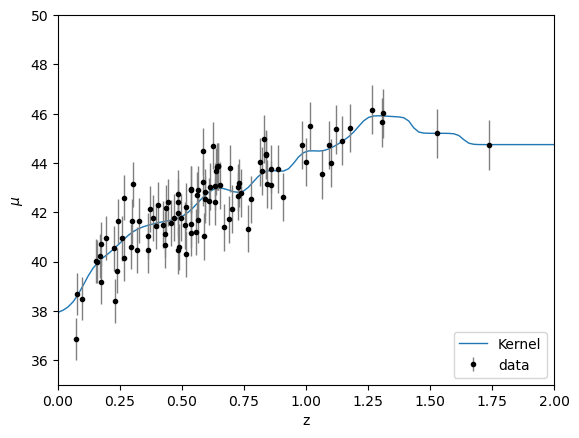

In [69]:
plt.plot(X_grid, y_pred_Watson, linewidth=1, label="Kernel")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [150]:
z_train, z_validation, mu_train, mu_validation = train_test_split(z_sample, np.array([mu_sample,dmu]).T, test_size=0.4, random_state=42) 

In [152]:
print(z_train.shape)
print(mu_train.shape)

(60,)
(60, 2)


In [154]:
# plot errors as a function of polynomial degree d
d = np.arange(0, 16)
training_err = np.zeros(d.shape)
val_err = np.zeros(d.shape)
d.shape

(16,)

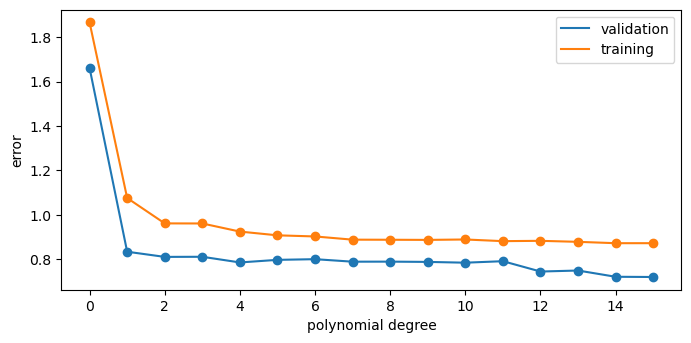

In [156]:
fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(z_sample, mu_sample, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, z_train) - mu_train[:, 0]) ** 2)
                              / len(mu_train))
    val_err[i] = np.sqrt(np.sum((np.polyval(p, z_validation) - mu_validation[:, 0]) ** 2)
                              / len(mu_validation))


ax = fig.add_subplot(211)
ax.plot(d,val_err, label='validation')
ax.plot(d, training_err, label='training')
ax.scatter(d, val_err)
ax.scatter(d, training_err)

ax.set_xlabel('polynomial degree')
ax.set_ylabel("error")
ax.legend()

In [166]:
#try again with linear regression 
lin_reg = LinearRegression()
lin_reg.fit(z_fit, mu_sample, dmu) #this is the model
X_grid = np.linspace(0,2,100).reshape(-1,1)
y_pred = lin_reg.predict(X_grid)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

y_train = theta0+theta1*z_train
y_validation = theta0+theta1*z_validation

In [168]:
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
val_err = np.zeros(d.shape)


fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(z_sample, mu_sample, d[i])
    training_err[i] = np.sqrt(np.sum((y_train - y_pred) ** 2)
                              / len(mu_train))
    crossval_err[i] = np.sqrt(np.sum((y_validation - y_pred) ** 2)
                              / len(mu_validation))


ax = fig.add_subplot(211)
ax.plot(d, val_err, label='cross-validation')
ax.plot(d, training_err, label='training')
ax.scatter(d, val_err, label='cross-validation')
ax.scatter(d, training_err, label='training')

ax.set_xlabel('polynomial degree')
ax.set_ylabel('error')
ax.legend(loc=2)

ValueError: operands could not be broadcast together with shapes (60,) (100,) 

<Figure size 800x800 with 0 Axes>